In [17]:
import os, pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Device ─────────────────────────────────────────────────
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"✅ Device: {device}")

# ── Paths ──────────────────────────────────────────────────
RESULTS_DIR = "../results/metrics"
MODELS_DIR  = "../models"
os.makedirs(MODELS_DIR, exist_ok=True)

# ── Load scalers ───────────────────────────────────────────
with open(f"{RESULTS_DIR}/scaler_X.pkl", 'rb') as f:
    scaler_X = pickle.load(f)
with open(f"{RESULTS_DIR}/scaler_y.pkl", 'rb') as f:
    scaler_y = pickle.load(f)

# ── Load cycle data ────────────────────────────────────────
df_all = pd.read_parquet(f"{RESULTS_DIR}/lab_cycles_labeled.parquet")

# ── Constants ──────────────────────────────────────────────
WINDOW       = 20
FEATURE_COLS = ['cap_Ah','v_mean','v_min','v_slope','i_mean',
                't_mean','t_max','energy_Wh','duration_min',
                'soc_start','soc_end']
N_FEATURES   = len(FEATURE_COLS)
EOL_SOH      = 0.80

print(f"✅ Artifacts loaded")
print(f"   Cycles: {len(df_all):,}  |  Features: {N_FEATURES}  |  Window: {WINDOW}")


✅ Device: mps
✅ Artifacts loaded
   Cycles: 213,995  |  Features: 11  |  Window: 20


In [18]:
# ── Feature cols — must match Notebook 02 exactly ───────────
FEATURE_COLS = ['cap_Ah','v_mean','v_min','v_slope','i_mean',
                't_mean','t_max','energy_Wh','duration_min',
                'soc_start','soc_end',
                'EFC_norm']
N_FEATURES = len(FEATURE_COLS)   # = 12

df_all = pd.read_parquet(f"{RESULTS_DIR}/lab_cycles_labeled.parquet")
print(f"EFC_norm present: {'EFC_norm' in df_all.columns}")

class LabBatteryDataset(Dataset):
    def __init__(self, df, scaler_X, scaler_y,
                 window=WINDOW, feature_cols=FEATURE_COLS, stride=10):
        self.samples = []
        for cell_id, grp in df.groupby('cell_id'):
            grp = grp.sort_values('EFC').reset_index(drop=True)
            X        = scaler_X.transform(grp[feature_cols].values)
            y        = scaler_y.transform(grp[['RUL']].values).flatten()
            efc_norm = grp['EFC_norm'].values          # ← Fix 1: needed for weighting

            for i in range(window, len(grp), stride):
                self.samples.append((
                    torch.tensor(X[i-window:i], dtype=torch.float32),
                    torch.tensor(y[i],          dtype=torch.float32),
                    torch.tensor(efc_norm[i],   dtype=torch.float32)  # ← NEW 3rd element
                ))

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx): return self.samples[idx]


train_ds = LabBatteryDataset(df_all[df_all['split']=='train'], scaler_X, scaler_y)
val_ds   = LabBatteryDataset(df_all[df_all['split']=='val'],   scaler_X, scaler_y)
test_ds  = LabBatteryDataset(df_all[df_all['split']=='test'],  scaler_X, scaler_y)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=0, pin_memory=False)

xb, yb, efcn = next(iter(train_loader))
print(f"✅ DataLoaders ready | X: {xb.shape}  y: {yb.shape}  efc_norm: {efcn.shape}")
print(f"   Train: {len(train_ds):,}  Val: {len(val_ds):,}  Test: {len(test_ds):,}")


EFC_norm present: True
✅ DataLoaders ready | X: torch.Size([64, 20, 12])  y: torch.Size([64])  efc_norm: torch.Size([64])
   Train: 15,798  Val: 2,955  Test: 2,329


In [19]:
pd.read_parquet(f"{RESULTS_DIR}/lab_cycles_labeled.parquet").columns.tolist()

['EFC',
 'cap_Ah',
 'v_mean',
 'v_min',
 'v_slope',
 'i_mean',
 't_mean',
 't_max',
 'energy_Wh',
 'duration_min',
 'soc_start',
 'soc_end',
 'SoH_est',
 'cap_est',
 'EFC_norm',
 'RUL',
 'EoL_EFC',
 'nominal',
 'cell_id',
 'split']

In [20]:
class PILSTM(nn.Module):
    """
    Physics-Informed LSTM for Battery RUL Estimation.
    Fix 2: warm-start hidden state via efc_norm embedding.
    """
    def __init__(self, input_size=12, hidden_size=64,
                 num_layers=2, dropout=0.4, fc_dims=[32, 16]):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        # Fix 2: maps efc_norm scalar → initial hidden state h0
        self.h0_embed = nn.Sequential(
            nn.Linear(1, hidden_size),
            nn.Tanh()
        )

        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            dropout     = dropout if num_layers > 1 else 0.0,
            batch_first = True
        )

        layers, in_dim = [], hidden_size
        for out_dim in fc_dims:
            layers += [nn.Linear(in_dim, out_dim), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = out_dim
        layers += [nn.Linear(in_dim, 1)]
        self.fc = nn.Sequential(*layers)

    def forward(self, x, efc_norm=None):
        if efc_norm is not None:
            h0 = self.h0_embed(efc_norm.unsqueeze(-1))           # (B, H)
            h0 = h0.unsqueeze(0).repeat(self.num_layers, 1, 1)   # (L, B, H)
            c0 = torch.zeros_like(h0)
            out, _ = self.lstm(x, (h0, c0))
        else:
            out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)


def monotonicity_loss(preds):
    if len(preds) < 2: return torch.tensor(0.0, device=preds.device)
    return torch.relu(preds[1:] - preds[:-1]).mean()

def capacity_physics_loss(preds, soh_proxy, nominal_rul=1.0):
    if len(preds) < 2: return torch.tensor(0.0, device=preds.device)
    soh_diff = soh_proxy[1:] - soh_proxy[:-1]
    rul_diff = preds[1:]    - preds[:-1]
    return torch.relu(-rul_diff * torch.sign(soh_diff + 1e-8)).mean()


model = PILSTM(
    input_size  = 12,
    hidden_size = 64,
    num_layers  = 2,
    dropout     = 0.4,
    fc_dims     = [32, 16]
).to(device)

xb_dev, _, efcn_dev = xb.to(device), yb.to(device), efcn.to(device)
with torch.no_grad():
    out = model(xb_dev, efcn_dev)
print(f"✅ PI-LSTM v2 (warm-start) ready")
print(f"   Input: {xb_dev.shape}  →  Output: {out.shape}")
print(f"   Params: {sum(p.numel() for p in model.parameters()):,}")


✅ PI-LSTM v2 (warm-start) ready
   Input: torch.Size([64, 20, 12])  →  Output: torch.Size([64])
   Params: 56,001


In [21]:
# Verify split distribution — run this before Cell 4
for s in ['train','val','test']:
    sub = df_all[df_all['split']==s]
    rul_orig = np.expm1(sub['RUL'])   # back to EFCs
    print(f"{s:5s}: {sub['cell_id'].nunique():3d} cells | "
          f"RUL mean={rul_orig.mean():.0f} "
          f"min={rul_orig.min():.0f} "
          f"max={rul_orig.max():.0f}")

train: 154 cells | RUL mean=0 min=0 max=2
val  :  26 cells | RUL mean=0 min=0 max=2
test :  26 cells | RUL mean=0 min=0 max=2


In [24]:
LR          = 5e-4
EPOCHS      = 80
PATIENCE    = 20
LAMBDA_MONO = 0.05
LAMBDA_CAP  = 0.02

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=4, factor=0.5)

def weighted_mae_loss(preds, targets, efc_norm):
    """Fix 1: early-life cycles (efc_norm < 0.4) weighted 3× more."""
    w = torch.where(efc_norm < 0.4,
                    torch.full_like(efc_norm, 1.5),
                    torch.ones_like(efc_norm))
    return (w * torch.abs(preds - targets)).mean()

history    = {'train_loss': [], 'val_loss': [], 'val_mae': []}
best_val   = float('inf')
patience_c = 0

print(f"🚀 Training PI-LSTM v2 for {EPOCHS} epochs on {device}")
print(f"   Weighted MAE (early×3) | warm-start h0 | patience={PATIENCE}\n")

for epoch in range(1, EPOCHS + 1):

    # ── Train ──────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    for xb, yb, efcn in train_loader:
        xb, yb, efcn = xb.to(device), yb.to(device), efcn.to(device)
        optimizer.zero_grad()
        preds     = model(xb, efcn)
        loss_data = weighted_mae_loss(preds, yb, efcn)
        loss_mono = monotonicity_loss(preds)
        loss_cap  = capacity_physics_loss(preds, xb[:, -1, 0], nominal_rul=1.0)
        loss      = loss_data + LAMBDA_MONO * loss_mono + LAMBDA_CAP * loss_cap
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss_data.item()
    train_loss /= len(train_loader)

    # ── Validate ───────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb, efcn in val_loader:
            xb, yb, efcn = xb.to(device), yb.to(device), efcn.to(device)
            preds     = model(xb, efcn)
            val_loss += weighted_mae_loss(preds, yb, efcn).item()
            all_preds.extend(preds.cpu().numpy())
            all_true.extend(yb.cpu().numpy())
    val_loss /= len(val_loader)

    p_rel   = scaler_y.inverse_transform(np.array(all_preds).reshape(-1,1)).flatten()
    t_rel   = scaler_y.inverse_transform(np.array(all_true).reshape(-1,1)).flatten()
    val_mae = mean_absolute_error(t_rel, p_rel)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_mae'].append(val_mae)
    scheduler.step(val_loss)

    if val_loss < best_val:
        best_val, patience_c = val_loss, 0
        torch.save(model.state_dict(), f"{MODELS_DIR}/best_pilstm_v2.pt")  # ← v2
    else:
        patience_c += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"train={train_loss:.4f} | val={val_loss:.4f} | "
              f"MAE={val_mae*100:.1f}%life | patience={patience_c}/{PATIENCE}")

    if patience_c >= PATIENCE:
        print(f"\n⏹ Early stopping at epoch {epoch}")
        break

print(f"\n✅ Training complete  |  Best val loss: {best_val:.4f}")
print(f"💾 Saved → models/best_pilstm_v2.pt")


🚀 Training PI-LSTM v2 for 80 epochs on mps
   Weighted MAE (early×3) | warm-start h0 | patience=20

Epoch   1/80 | train=0.3012 | val=0.1197 | MAE=3.6%life | patience=0/20
Epoch   5/80 | train=0.2823 | val=0.1132 | MAE=3.1%life | patience=0/20
Epoch  10/80 | train=0.2757 | val=0.1128 | MAE=3.2%life | patience=0/20
Epoch  15/80 | train=0.2668 | val=0.1208 | MAE=3.2%life | patience=1/20
Epoch  20/80 | train=0.2669 | val=0.1039 | MAE=3.0%life | patience=6/20
Epoch  25/80 | train=0.2556 | val=0.1276 | MAE=3.5%life | patience=11/20
Epoch  30/80 | train=0.2541 | val=0.0994 | MAE=2.8%life | patience=16/20

⏹ Early stopping at epoch 34

✅ Training complete  |  Best val loss: 0.0891
💾 Saved → models/best_pilstm_v2.pt


TEST SET RESULTS — PI-LSTM v2 (KIT NMC Lab)
  MAE   : 0.0278  (2.8% of remaining life)
  RMSE  : 0.0329  (3.3% of remaining life)
  R²    : 0.9898
  MAPE  : 1600.5%
💾 Predictions → results/metrics/test_predictions_v2.csv


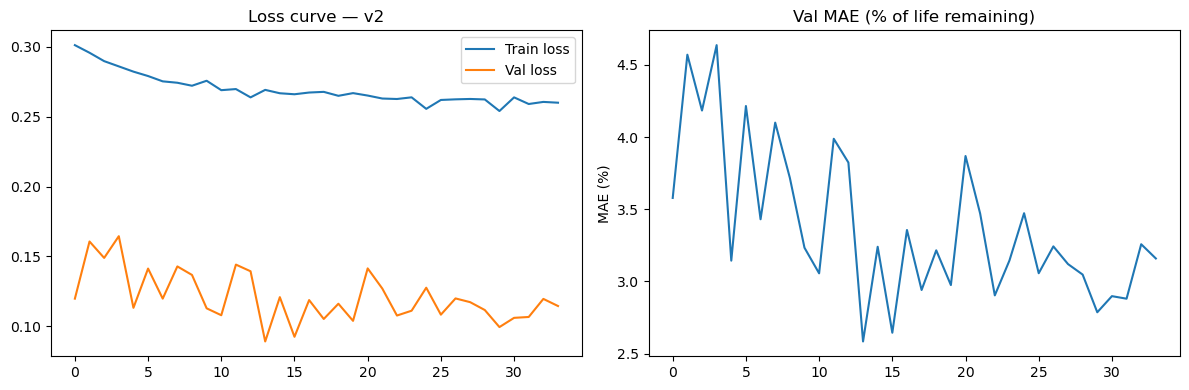

💾 Training curve → results/figures/training_curve_v2.png


In [25]:
# ── Change 1: load v2 checkpoint ───────────────────────────
model.load_state_dict(torch.load(f"{MODELS_DIR}/best_pilstm_v2.pt",   # ← _v2
                                  map_location=device))
model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb, efcn in test_loader:                    # ← unpack 3 values
        xb, efcn = xb.to(device), efcn.to(device)
        p = model(xb, efcn).cpu().numpy()               # ← pass efcn to model
        all_preds.extend(p)
        all_true.extend(yb.numpy())

# ── Everything below is UNCHANGED ──────────────────────────
p_rel = scaler_y.inverse_transform(
            np.array(all_preds).reshape(-1,1)).flatten()
t_rel = scaler_y.inverse_transform(
            np.array(all_true).reshape(-1,1)).flatten()
p_rel = np.clip(p_rel, 0, 1)
t_rel = np.clip(t_rel, 0, 1)

mae  = mean_absolute_error(t_rel, p_rel)
rmse = np.sqrt(mean_squared_error(t_rel, p_rel))
r2   = r2_score(t_rel, p_rel)
mape = np.mean(np.abs(t_rel - p_rel) / (t_rel + 1e-3)) * 100

print("=" * 48)
print("TEST SET RESULTS — PI-LSTM v2 (KIT NMC Lab)")
print("=" * 48)
print(f"  MAE   : {mae:.4f}  ({mae*100:.1f}% of remaining life)")
print(f"  RMSE  : {rmse:.4f}  ({rmse*100:.1f}% of remaining life)")
print(f"  R²    : {r2:.4f}")
print(f"  MAPE  : {mape:.1f}%")
print("=" * 48)

pd.DataFrame({'true_RUL': t_rel, 'pred_RUL': p_rel}).to_csv(
    f"{RESULTS_DIR}/test_predictions_v2.csv", index=False)  # ← _v2 to avoid overwriting
print(f"💾 Predictions → results/metrics/test_predictions_v2.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='Train loss')
axes[0].plot(history['val_loss'],   label='Val loss')
axes[0].set_title('Loss curve — v2'); axes[0].legend()
axes[1].plot([m*100 for m in history['val_mae']])
axes[1].set_title('Val MAE (% of life remaining)')
axes[1].set_ylabel('MAE (%)')
plt.tight_layout()
plt.savefig("../results/figures/training_curve_v2.png", dpi=150)
plt.show()
print("💾 Training curve → results/figures/training_curve_v2.png")


In [26]:
import shutil
shutil.copy("../models/best_pilstm_v2.pt", "../models/best_pilstm_final.pt")

'../models/best_pilstm_final.pt'